In [1]:
using Revise
using SSMCMain, SSMCMain.ModifiedMiCRM

In [2]:
using CairoMakie, ProgressLogging
using Base.Threads
using BenchmarkTools
using JLD2, Geppetto
using Random, Distributions, Statistics

In [3]:
using GLMakie
CairoMakie.activate!()
# display(GLMakie.Screen(), f.figure)

# ODE/PDE Solving

## Setup

In [4]:
function random_matrix_initialization(S, M, c_sparsity=1.0, l_sparsity=0.35)
    # 110425 to start let us just randomly draw D and c without structure
    # similarly, we will generate some random guesses for the other parameters

    # constant dilution rate
    rnd = rand()
    r = fill(rnd,M)

    # universal death rate
    rnd2 = rand()
    m = rnd2

    # for simplicity, lets start with a single fed resource
    # chemostat feed rate 
    #K = fill(0.,M)
    #K[1] = 1.

    # lets allow resources some variability
    #K_dist = truncated(Normal(0.5,0.1), 0.0, 1.0)
    K_dist = Beta(0.1,0.3)
    K = rand(K_dist, M)


    # leakage now. Lets assume its a pretty flat probability distribution
    leak = Beta(0.2/l_sparsity,0.2)
    l = rand(leak,(S,M))

    # most values around 0. This is essentially a proxy for sparsity
    c_i_alpha = Beta(0.5/c_sparsity,0.5)
    c = rand(c_i_alpha,(S,M))
    
    # finally, the most complicated distribution
    D = fill(0.,(S,M,M))
    for i in 1:S
        for j in 1:M
            if c[i,j] > 0
                flag = true
                while flag
                    for k in 1:M
                        if j == k
                            D[i,k,j] = 0.0
                        else
                            D[i,k,j] = rand(Beta(0.5/(M/5),0.5))
                        end
                    end
                    # check if the sum of the row is less than 1
                    if sum(D[i,:,j]) < 1.0
                        flag = false
                    end
                end
            end

        end
    end


    Ds = fill(0.,(S+M))
    Ds[1:S] .= 1e-5
    Ds[1+S] = 100
    Ds[S+2:S+M] .= 10

    return r, m, K, l, c, D, Ds

   
    

end

random_matrix_initialization (generic function with 3 methods)

In [5]:
function BinaryRandomMatrix(a,b, p)
    # Generate a random binary matrix of size a x b with probability of 1 = p
    r = rand(a, b)
    m = fill(0, a, b)

    for i in 1:a
        for j in 1:b
            if r[i,j] < p
                m[i,j] = 1
            end
        end
    end
    
    return  m
end

BinaryRandomMatrix (generic function with 1 method)

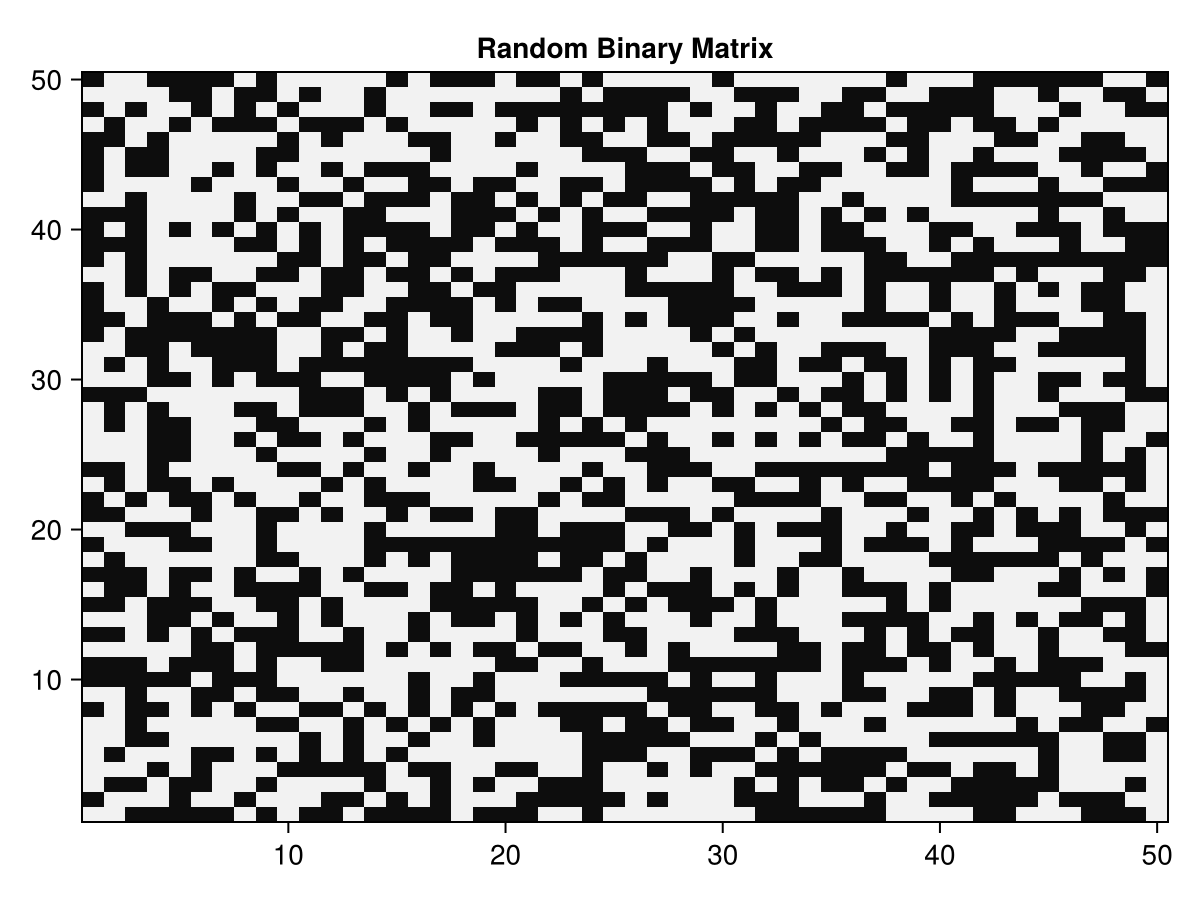

CairoMakie.Screen{IMAGE}


In [6]:
test = BinaryRandomMatrix(50, 50, 0.5)

#visualize
f = Figure()
ax = Axis(f[1, 1], title = "Random Binary Matrix")
heatmap!(ax, test, colormap = :grays)
f[1, 1] = ax
display(f)

Dirichlet: [0.38291521607484913, 0.12901102045983745, 0.13231907029745674, 0.06962405660303603, 0.015436448900669874, 0.0257349294255938, 0.021049849623704004, 0.021696000563232506, 0.12002732910094897, 0.00642213273720424, 9.09517816208196e-19, 1.1745393697524949e-20, 1.4817656123537098e-45, 1.3994144185637383e-72, 3.4224997095454366e-77, 0.005181530229711521, 0.056556168762378005, 0.0006097815106973642, 4.3361217706162694e-19, 2.118943116584773e-53, 2.279862702672876e-183, 5.041520323524154e-143, 6.542180917792655e-42, 1.416151224307066e-29, 3.235669472815728e-23, 4.5640850534035485e-67, 2.0190581225245555e-22, 1.2328850540338268e-105, 1.9948845846375164e-75, 2.2064940461809306e-84, 7.217340322729053e-23, 4.7011261043421036e-11, 0.013415594900468895, 2.973625782770135e-17, 8.707272809691364e-7, 3.239217188401137e-90, 6.212849876937973e-57, 3.2441651734060296e-128, 6.921769269261643e-42, 7.184037844513206e-79, 4.580674340690989e-108, 2.84683465534224e-11, 3.8396928571839863e-165, 1.37

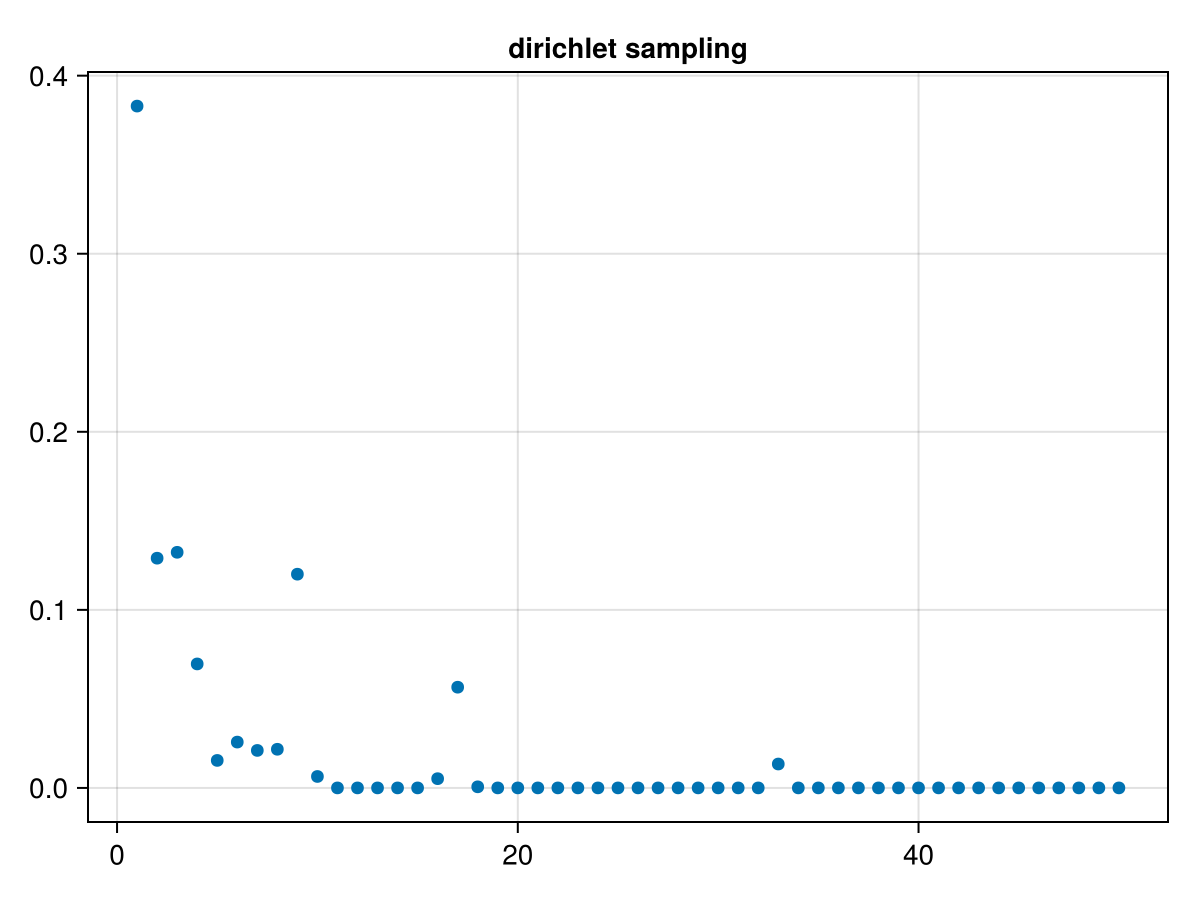

dirichlet sum 1.0


In [7]:
# testing dirichlet distribution

L = 10
M = 50

arr = fill(0.,M)
for i in 1:M
    if i<=L
        arr[i] = 0.5
    else
        arr[i] = 0.01
    end
end

dir = rand(Dirichlet(arr))
println("Dirichlet: ", dir)
f = Figure()
ax = Axis(f[1, 1], title = "dirichlet sampling")
plot!(ax, dir, colormap = :grays)
f[1, 1] = ax
display(f)

println("dirichlet sum ", sum(dir))

In [94]:
function marsland_initialization(S, M,SA = 5,MA = 5, q = 0.9, c0=0.,c1=1., muc = 10,
        fs = 0.45, fw=0.45,sparsity=0.2,l=0.8)
    # To start we are going to make a speciofic subset of assumptions available in the Marsland and Cui code.


    # let us begin by assigning the whole array c0
    c = fill(c0/M,(S,M))
    
    # now we will calculate the block structure of the matrix
    F = ceil(M/MA) #number of resource classes
    T = ceil(S/SA) #number of species classes
    S_overlap = S%SA # number of species in the last class
    M_overlap = M%MA # number of resources in the last class
    # we will always assume that the last species class is the "general" class 
    println("T: ", T, " F: ", F)

    # we will sample the consumption matrix in block form
    
    for tt in 1:T
        for ff in 1:F
            if tt != T
                if ff == tt
                    p = muc/(M*c1)*(1+q*(M-MA)/M)
                else
                    p = muc/(M*c1)*(1-q)
                end

                if ff*MA > M
                    # ensure that the last block is not larger than the matrix
                    block = BinaryRandomMatrix(SA,M_overlap,p)
                    c[Int(1+SA*(tt-1)):Int(tt*SA), Int(1+MA*(ff-1)):Int(M)] .= block
                else
                    block = BinaryRandomMatrix(SA,MA,p)
                    c[Int(1+SA*(tt-1)):Int(tt*SA), Int(1+MA*(ff-1)):Int(ff*MA)] .= block
                end

            else
                # generalist class
                p = muc/(M*c1)
                if S_overlap != 0
                    block = BinaryRandomMatrix(S_overlap,M,p)
                    c[Int(1+SA*(tt-1)):Int(S), :] .= block
                else
                    
                    block = BinaryRandomMatrix(SA,M,p)
                    c[Int(1+SA*(tt-1)):Int(tt*SA), :] .= block
                end
            end
        end
    end
    

    # Time for D_iab
    strain_class = 0
    D = fill(0.,(S,M,M))
    for i in 1:S
        if (i-1)%SA ==0
            strain_class += 1
            #println("Class: ", class, " i: ", i)
        end

        resource_class = 0
        for j in 1:M
            if (j-1)%MA == 0
                resource_class +=1
            end

            #start with background levels
            bkg = (1-fw-fs)/(M - MA)
            p = fill(bkg,M)
            
            if resource_class == strain_class
                if strain_class == T
                    if M_overlap != 0
                        p[(M-M_overlap):M] .= fw + fs
                    else
                        p[(M-MA):M] .= fw + fs
                    end
                else
                    #the within class resource
                    upper_limit = minimum(((strain_class-1)*MA+MA,M))
                    p[1+(strain_class-1)*MA:upper_limit] .= fs

                    # the waste resources
                    if M_overlap != 0
                        p[(M-M_overlap):M] .= fw
                    else
                        p[(M-MA):M] .= fw
                    end
                end
            else
                p = fill(1.,M)
            end
            


            #lets sample the distribution
            vec = rand(Dirichlet(p))
            D[i,:,j] = vec

        end
    end
    

    # constant dilution rate
    rnd = rand()
    r = fill(rnd,M)

    # universal death rate
    rnd2 = rand()
    m = rnd2

    # for simplicity, lets start with a single fed resource
    # chemostat feed rate 
    #K = fill(0.,M)
    #K[1] = 1.

    # lets allow resources some variability
    #K_dist = truncated(Normal(0.5,0.1), 0.0, 1.0)
    K_dist = Beta(0.1,0.3)
    K = rand(K_dist, M)
    # K ./= 2.

    # leakage now. Lets assume its a pretty flat probability distribution
    leak = Beta(0.2/sparsity,0.2)
    l = rand(leak,(S,M))

    Ds = fill(0.,(S+M))
    Ds[1:S] .= 1e-6
    Ds[(S+1):(S+M)] .= 1e-3
    for a in 1:M
        if K[a] > 0.5
            Ds[S+a] = 1.
        end
    end
    # Ds[1+S] = 1
    # Ds[S+2:S+M] .= 0.1

    return r, m, K, l, c, D, Ds

end

marsland_initialization (generic function with 11 methods)

T: 3.0 F: 3.0


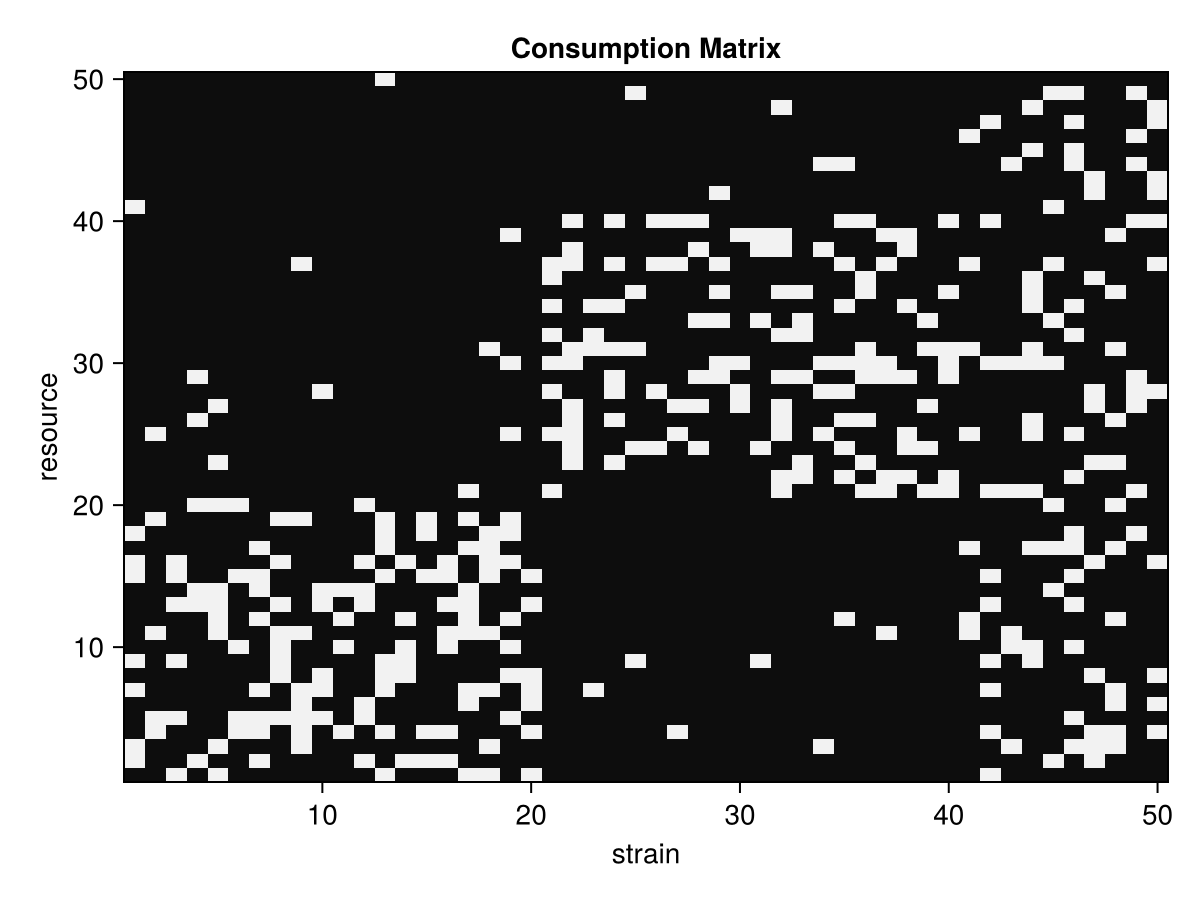

shape av: (1, 50, 50)


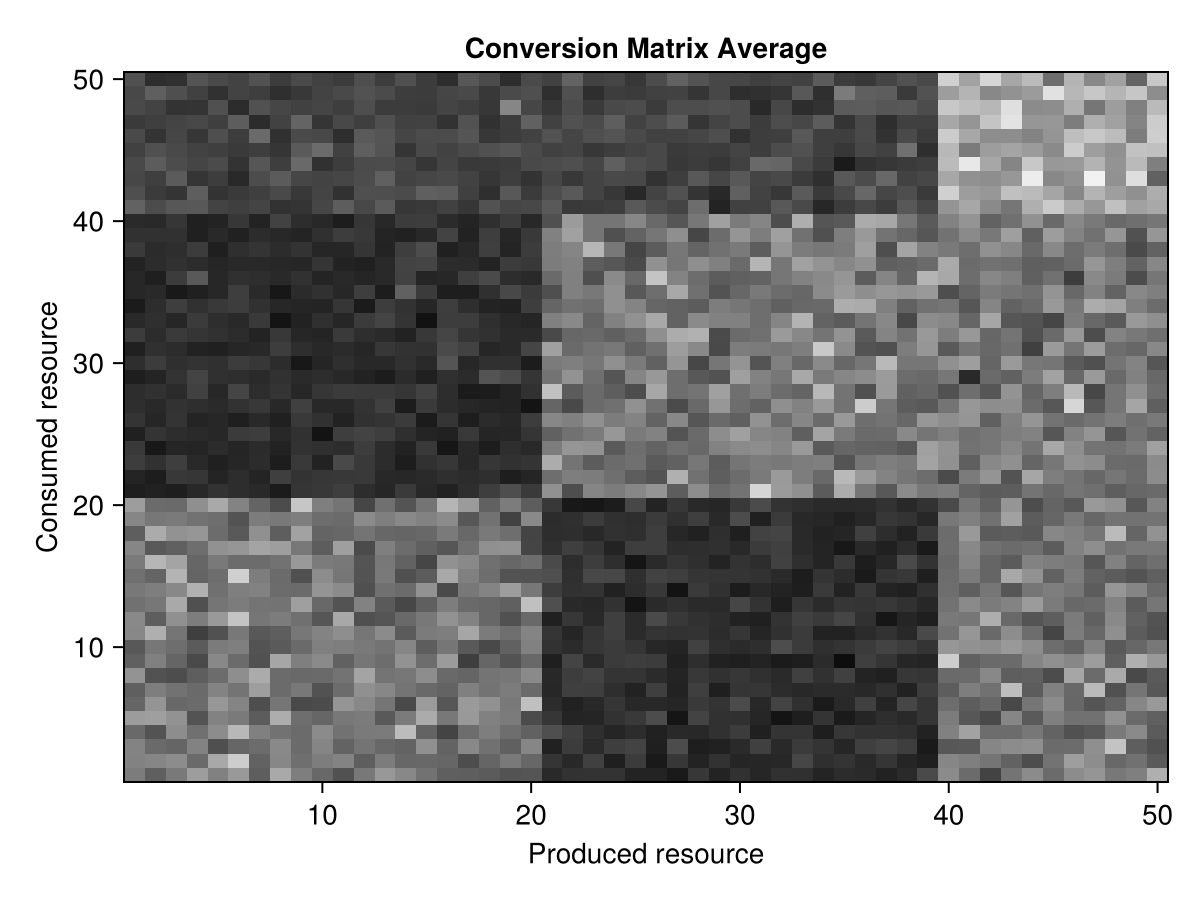

CairoMakie.Screen{IMAGE}


In [95]:
r, m, K, l, c, D, Ds = marsland_initialization(50,50,20,20)

# let's visualize the consumption matrix
f = Figure()
ax = Axis(f[1, 1], xlabel="strain", ylabel="resource", title = "Consumption Matrix")
heatmap!(ax, c, colormap = :grays)
#ax.yreversed = true
f[1, 1] = ax
display(f)
# let's visualize the leakage matrix
av = mean(D,dims=1)
println("shape av: ", size(av))
f = Figure()
ax = Axis(f[1, 1], xlabel="Produced resource", ylabel="Consumed resource", title = "Conversion Matrix Average")
heatmap!(ax, av[1,:,:], colormap = :grays)
#ax.yreversed = true
f[1, 1] = ax
display(f)


## Generating and solving a single sample

In [96]:
# initialize the parameters
S = 50
M = 50
#r, m, K, l, c, D, Ds = random_matrix_initialization(S,M)
r, m, K, l, c, D, Ds = marsland_initialization(S,M,10,10)
diffusions = Ds;
# diffusions = [fill(0., S); fill(1., M)];
# diffusions = [fill(1e-6, S); fill(1., M)];

T: 5.0 F: 5.0


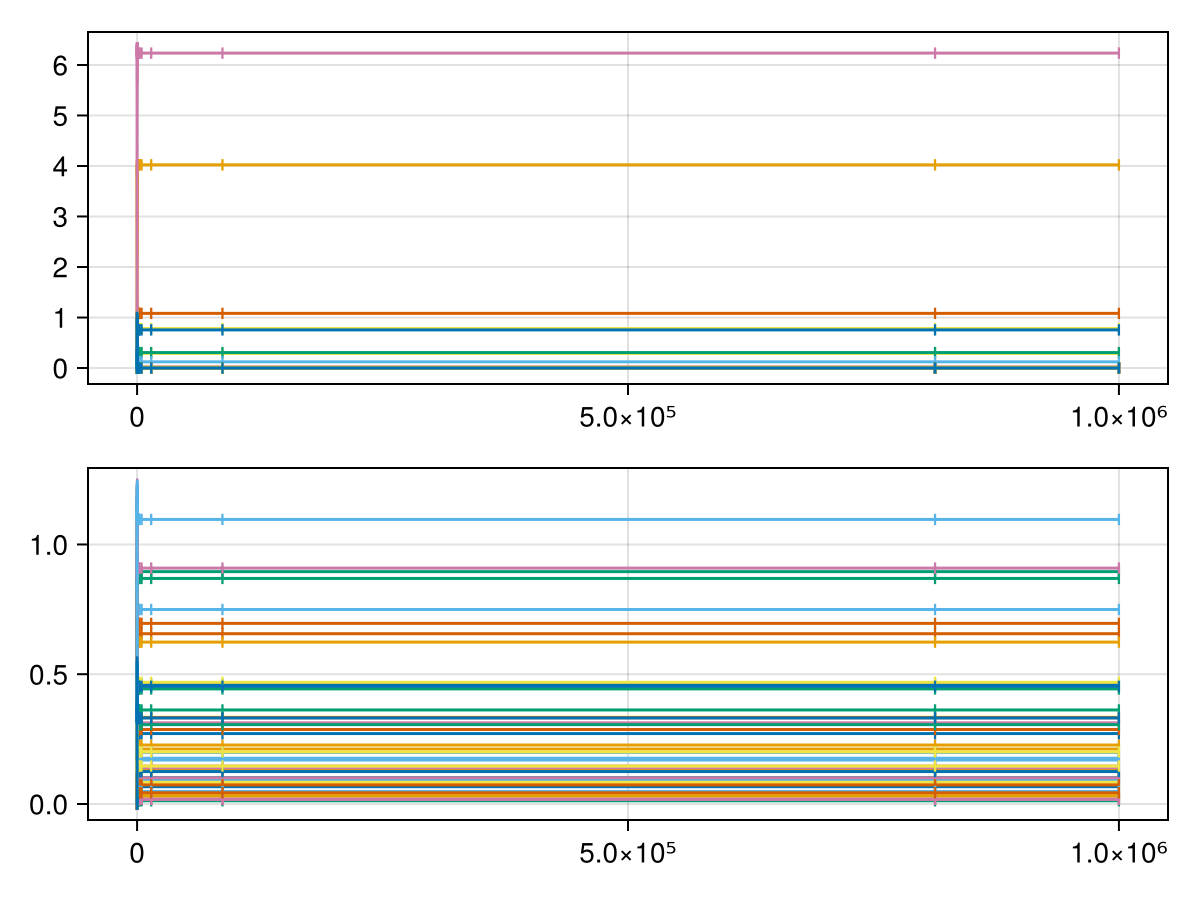

In [97]:
ps = BMMiCRMParams(fill(1., S), fill(1., M), fill(m, S), K, r, l, c, D)
# ps = unstable_ps[1]
# Ds = unstable_Ds[1]
diffusions = Ds
p = make_mmicrm_problem(ps, [fill(1., S); fill(0., M)], 1000000);
s = solve(p)
# check_mmicrmparams(p.p)
# display(s[end])
plot_mmicrm_sol(s).figure

## Linear stability analysis

In [98]:
usol = s[end]
xx = uninplace(mmicrmfunc!)(usol, p.p, 0)
@show maximum(xx);

maximum(xx) = 7.331357743112221e-13


In [99]:
ks = 10 .^ range(-5, 2, 100)
lsfunc = linstab_make_k_func(p.p, diffusions, usol)
@time lambdas = lsfunc.(ks);
mrls = map(lambdas) do ls
    maximum(real, ls)
end
mrl0 = mrls[1]
mmrl = maximum(mrls)
@show mmrl;

  0.185991 seconds (1.30 k allocations: 4.266 MiB)
mmrl = -0.00023540652942035008


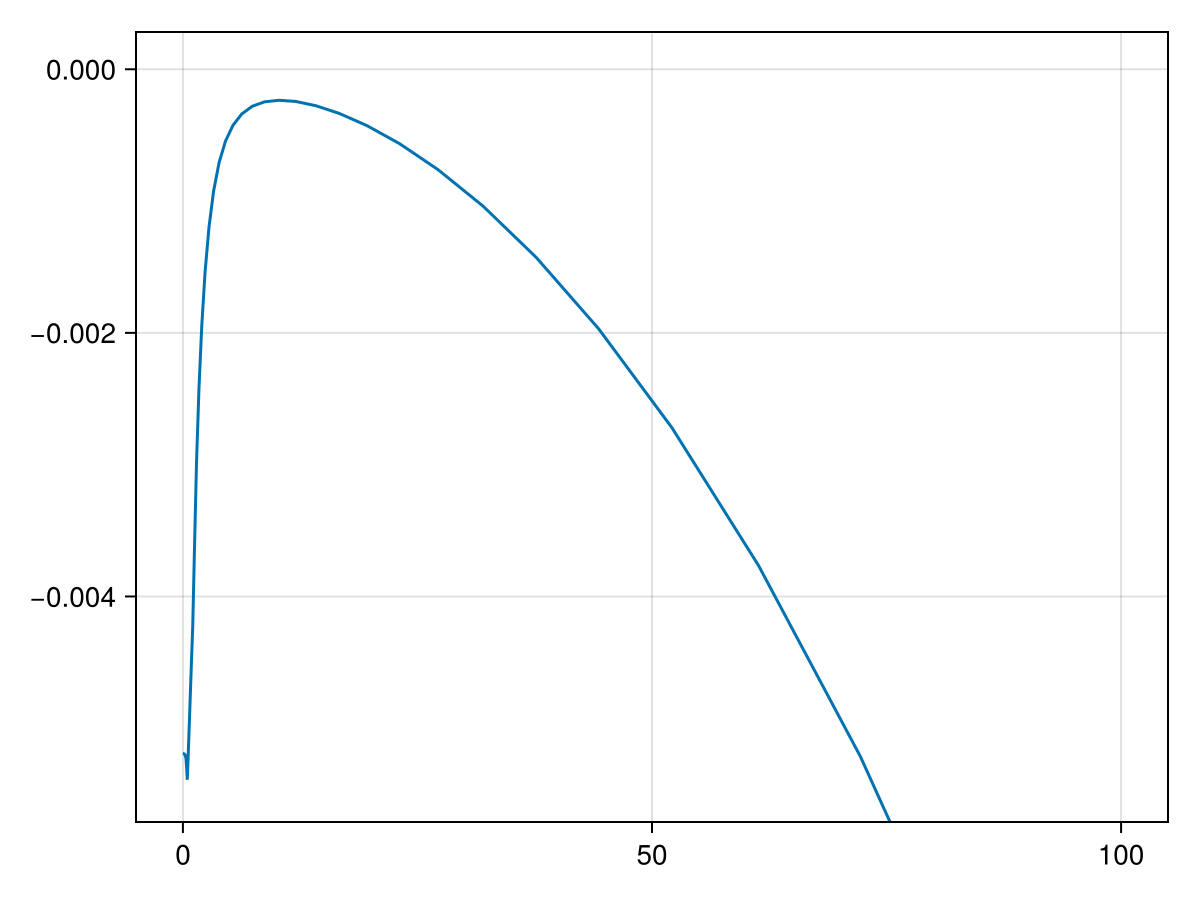

In [100]:
fap = lines(ks, mrls)
if mmrl > 0.
    ylims!(fap.axis, abs(mmrl) .* (-2., 2.))
else
    ylims!(fap.axis, (mrl0 * 1.1, abs(mmrl) * 1.2))
end
# fap.axis.xscale = log10
# display(GLMakie.Screen(), fap)
fap

## Probability of instability!

In [101]:
# We are going to run a set of replicates to see how probable instability is
nrep = 100

S = 20
M = 20  

instability = fill(0., nrep)

unstable_ps = []
unstable_Ds = []

for ii in 1:nrep
    # initialize the parameters
    r, m, K, l, c, D, Ds = random_matrix_initialization(S,M)

    ps = BMMiCRMParams(fill(1., S), fill(1., M), fill(m, S), K, r, l, c, D)
    p = make_mmicrm_problem(ps, [fill(1., S); fill(0., M)], 1000000);
    s = solve(p)
    # check_mmicrmparams(p.p)

    usol = s[end]

    # check the stability
    ks = 10 .^ range(-5, 2, 100)
    # ks = LinRange(0., 40., 1000)
    lsfunc = linstab_make_k_func(p.p, Ds, usol)
    lambdas = lsfunc.(ks);
    mrls = map(lambdas) do ls
        maximum(real, ls)
    end
    mmrl = maximum(mrls)

    if mmrl > 0
        instability[ii] = 1.
        push!(unstable_ps, ps)
        push!(unstable_Ds, Ds)
    else
        instability[ii] = 0.
    end
    #println("replicate ", ii, " of ", nrep, " done")
end

println("fraction instability: ", sum(instability)/nrep)


fraction instability: 0.0


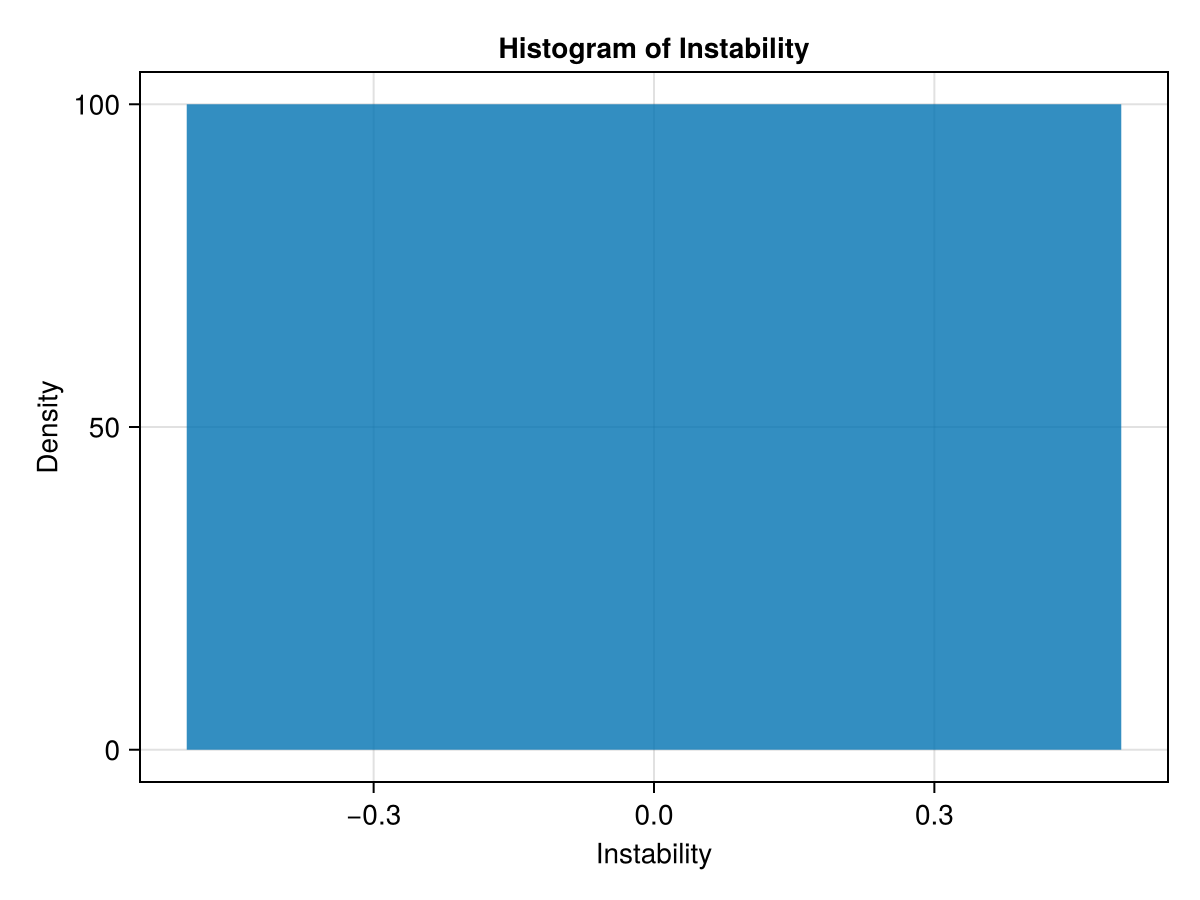

In [20]:
# check the histogram of instability
f = Figure()
ax = Axis(f[1, 1], title="Histogram of Instability", xlabel="Instability", ylabel="Density")
hist!(ax, instability, bins=2)#, normalization = :pdf)
f

In [ ]:
# Now we'll see % instability as a function of size

species = collect(2:10)
println("species: ", species)
nspecies = length(species)

perc_instability = fill(0., nspecies)


for x in 1:nspecies

    println(x)
    nrep = 1000

    S = species[x]
    M = species[x]

    println(S, " species")
    println(M, " resources")

    instability = fill(0., nrep)

    for ii in 1:nrep
        # initialize the parameters
        r, m, K, l, c, D, Ds = random_matrix_initialization(S,M)

        # create the model
        p = make_mmicrm_smart(S, M, 10000;
            D, c, l,
            K,r,m,
            u0=:onlyN,
            u0rand=0.
        )
        s = solve(p)

        usol = s[end]

        # check the stability
        ks = LinRange(0., 40., 4000)
        lambdas = do_linstab_for_ks(ks, p, Ds, usol);

        if maximum(real(lambdas)) > 0
            instability[ii] = 1.
        else
            instability[ii] = 0.
        end
        #println("replicate ", ii, " of ", nrep, " done")
    end


    perc_instability[x] = sum(instability)/nrep

    println("finished replicates for ", S, " species")
    println("fraction instability: ", perc_instability[x])
    
end

species: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
1
2 species
2 resources
finished replicates for 2 species
fraction instability: 0.015
2
4 species
4 resources
finished replicates for 4 species
fraction instability: 0.024
3
6 species
6 resources
finished replicates for 6 species
fraction instability: 0.017
4
8 species
8 resources
finished replicates for 8 species
fraction instability: 0.017
5
10 species
10 resources
finished replicates for 10 species
fraction instability: 0.017
6
12 species
12 resources
finished replicates for 12 species
fraction instability: 0.023
7
14 species
14 resources
finished replicates for 14 species
fraction instability: 0.017
8
16 species
16 resources
finished replicates for 16 species
fraction instability: 0.018
9
18 species
18 resources
finished replicates for 18 species
fraction instability: 0.019
10
20 species
20 resources
finished replicates for 20 species
fraction instability: 0.014


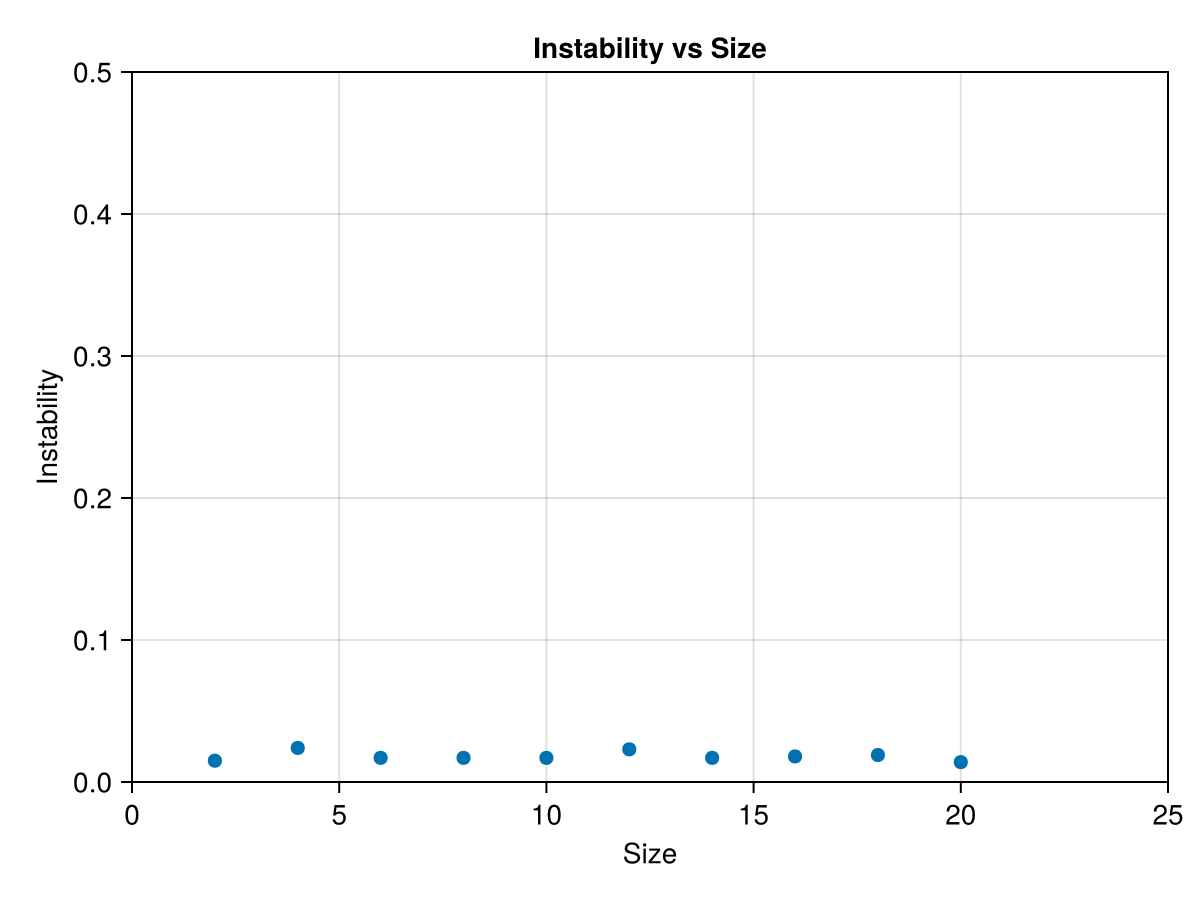

In [50]:
# plot the results
f = Figure()
ax = Axis(f[1, 1], title="Instability vs Size", xlabel="Size", ylabel="Instability")
scatter!(ax, species, perc_instability, markersize=10)
ylims!(ax, (0., 0.5))
xlims!(ax, (0., 25.))
f

In [55]:
# now let's see how the instability changes with sparsity and average leakage

nc = 5
nl = 5

repeats = 3
nrep = 20

instability = fill(0., (nc,nl,repeats,nrep))

for i in 1:nc
    c_sparsity = i/nc
    for j in 1:nl
        l_sparsity = j/nl
        for k in 1:repeats
            for q in 1:nrep
          
                # initialize the parameters
                S = 10
                M = 10

                r, m, K, l, c, D, Ds = random_matrix_initialization(S,M,c_sparsity,l_sparsity)

                # create the model
                p = make_mmicrm_smart(S, M, 500;
                    D, c, l,
                    K,r,m,
                    u0=:onlyN,
                    u0rand=0.
                )
                s = solve(p)
                usol = s[end]
                # check the stability
                ks = LinRange(0., 40., 10000)
                lambdas = do_linstab_for_ks(ks, p, Ds, usol)
                if maximum(real(lambdas)) > 0
                    instability[i,j,k,q] = 1.
                else
                    instability[i,j,k,q] = 0.
                end
                #println("replicate ", ii, " of ", nrep, " done")
            end
        end
    
    end
end



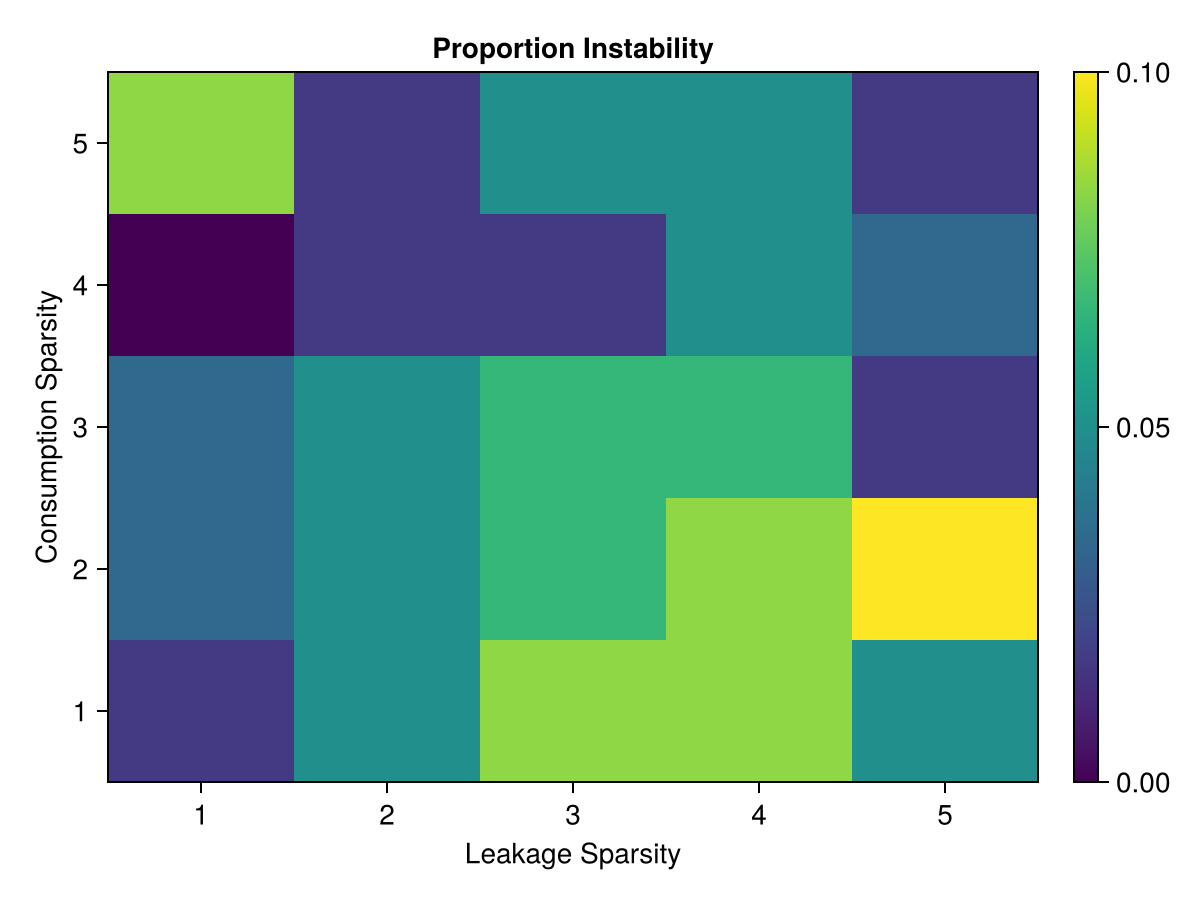

In [57]:
# lets plot the heatmap

# first we need to average over the repeats
instability_avg = fill(0., (nc,nl))
for i in 1:nc
    for j in 1:nl
        instability_avg[i,j] = sum(instability[i,j,:,:])/(repeats*nrep)
    end
end

# now we can plot the heatmap
fig, ax, hm = heatmap(instability_avg, colormap = :viridis, axis = (title = "Proportion Instability", xlabel = "Leakage Sparsity", ylabel = "Consumption Sparsity"))
Colorbar(fig[:, end+1], hm)
fig



## Spatial stuff - 1D!

In [65]:
usol = s[end]
show(uninplace(mmicrmfunc!)(usol, p.p, 0))

[7.550873896409062e-32, 4.2502421403944015e-31, 1.9487841106305623e-59, -2.6258698916770404e-17, 6.430415121292594e-31, -1.0769381380222485e-52, -6.418359717629122e-31, 9.030289895626577e-33, -1.9573263636332449e-28, -1.1870512823977152e-16, -8.837225320414412e-16, -2.31752018493873e-53, -2.3280739385093474e-51, -4.874035865865249e-32, -1.2711217274049357e-52, -2.2091700937373274e-24, -1.6296325380589784e-24, 5.635954982422246e-52, 7.800325350770289e-57, 9.851183687727111e-32, 5.551115123125783e-17, 1.6653345369377348e-16, 5.551115123125783e-17, 5.551115123125783e-17, 0.0, -2.7755575615628914e-16, 1.3877787807814457e-17, 0.0, 5.551115123125783e-17, -8.326672684688674e-17, -1.3877787807814457e-16, 1.3877787807814457e-17, 5.551115123125783e-17, -6.938893903907228e-17, 4.163336342344337e-17, 4.163336342344337e-17, 2.7755575615628914e-17, 5.551115123125783e-17, -8.326672684688674e-17, -1.3877787807814457e-17]

In [69]:
ssize = (1000,)
su0 = expand_u0_to_size(ssize, usol)
psu0 = perturb_u0_uniform(get_Ns(p.p)..., su0, 0.1, 0.1)

spatial_ps = BSMMiCRMParams(p.p,
    diffusions,
    make_cartesianspace_smart(1; dx=0.1),
    prod(ssize) >= 100 ? nthreads() : nothing
)

sp = make_smmicrm_problem(spatial_ps, psu0, 10000000)

size(sp.u0), sp.p.usenthreads, sp.p.space

((40, 1000), 18, CartesianSpace{1, Tuple{Periodic}, Float64}([0.1]))

#### Direct solver

In [70]:
@time sps = solve(sp, QNDF(); maxiters=1000)
print_spatial_solution_stats(sps)

 34.767848 seconds (241.91 k allocations: 9.839 GiB, 1.12% gc time)
Success
nf is 1594
solution has 239 saved states
max resid is 2.17071e-08


┌ Warning: reaching negative values, minimum is -0.0999966
└ @ SSMCMain.ModifiedMiCRM ~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/src/SSMCMain/src/ModifiedMiCRM/util.jl:10


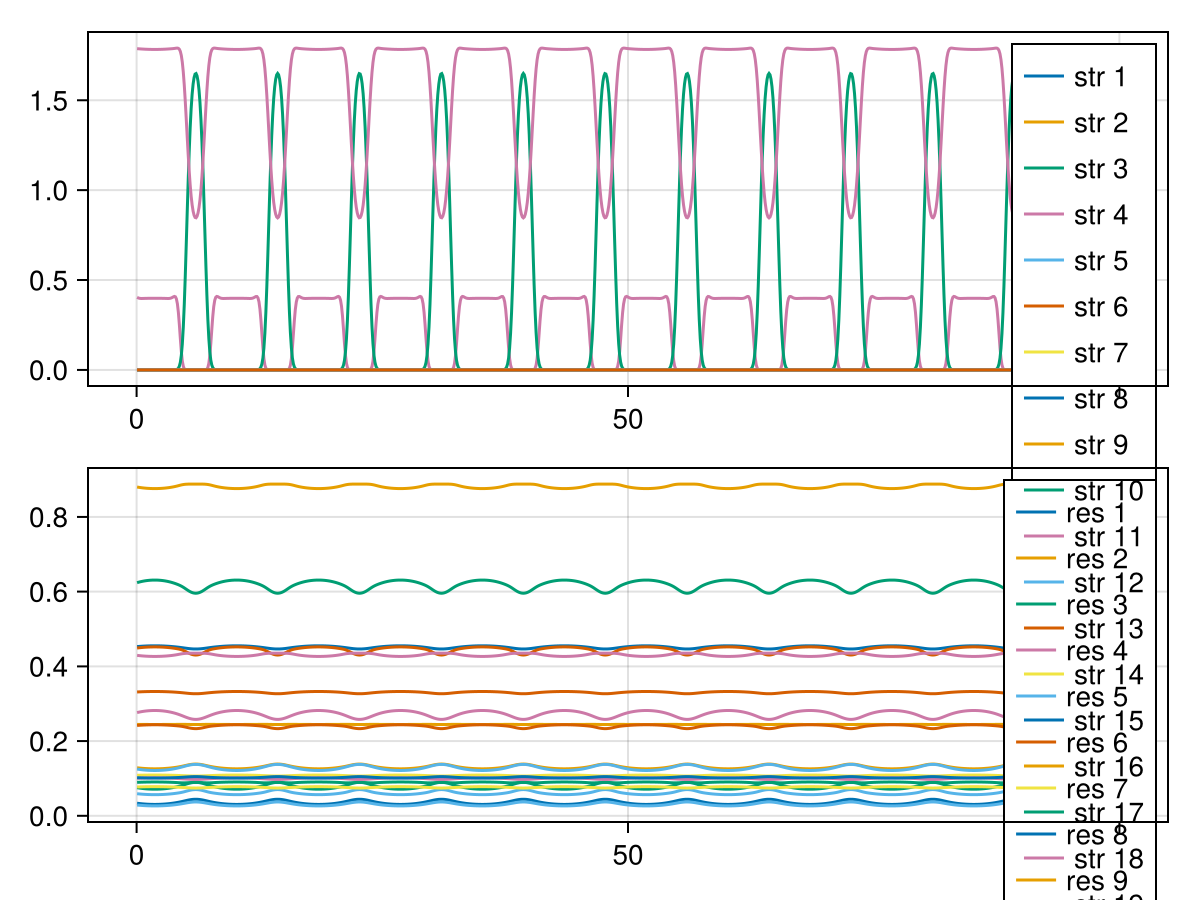

In [71]:
faa = plot_1dsmmicrm_sol_snap(sps.prob.p, sps(sps.t[end]))

In [136]:
display(GLMakie.Screen(), faa)

GLMakie.Screen(...)

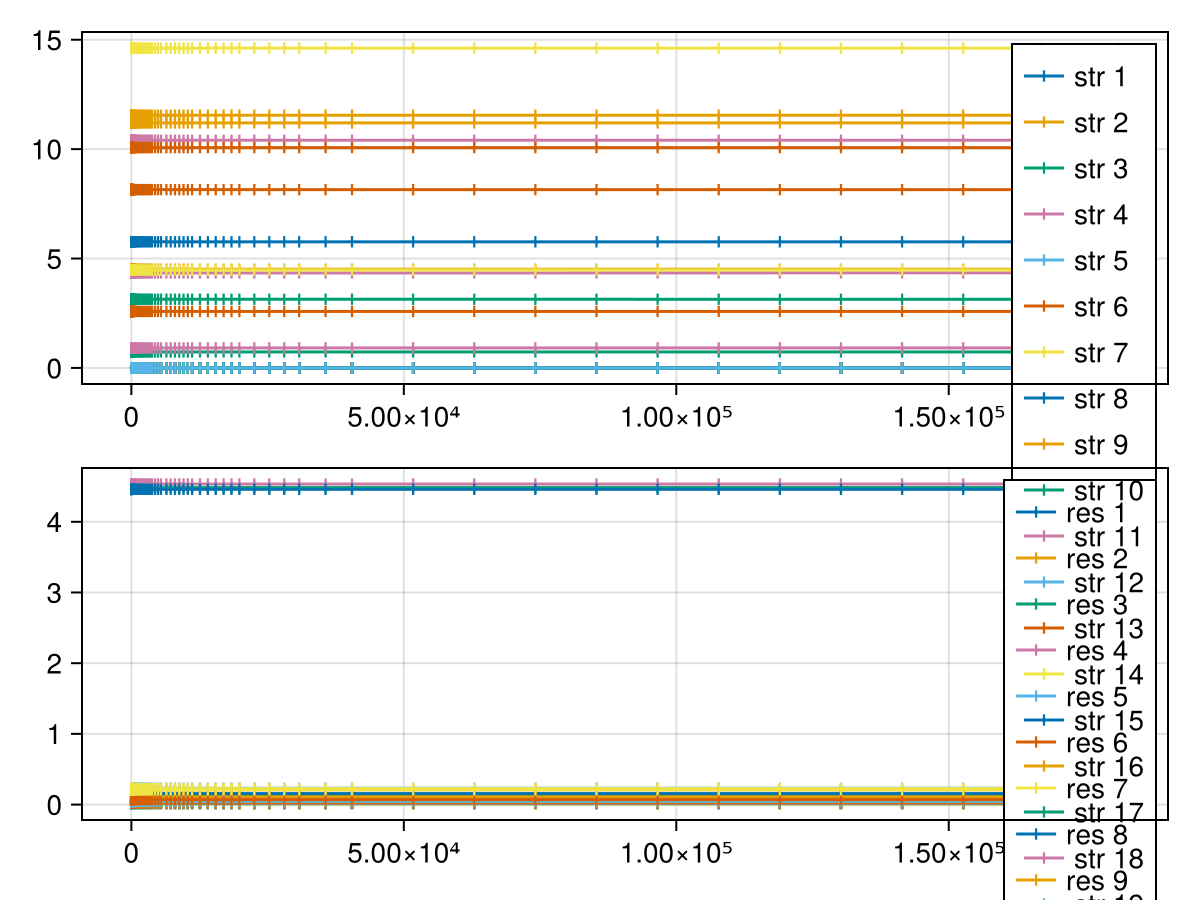

In [56]:
plot_smmicrm_sol_avgs(sps, 1:170)

#### Steady state solver

ReturnCode.Success = 1

1656

  2.612578 seconds (10.12 M allocations: 1012.315 MiB, 10.17% gc time, 77.99% compilation time)


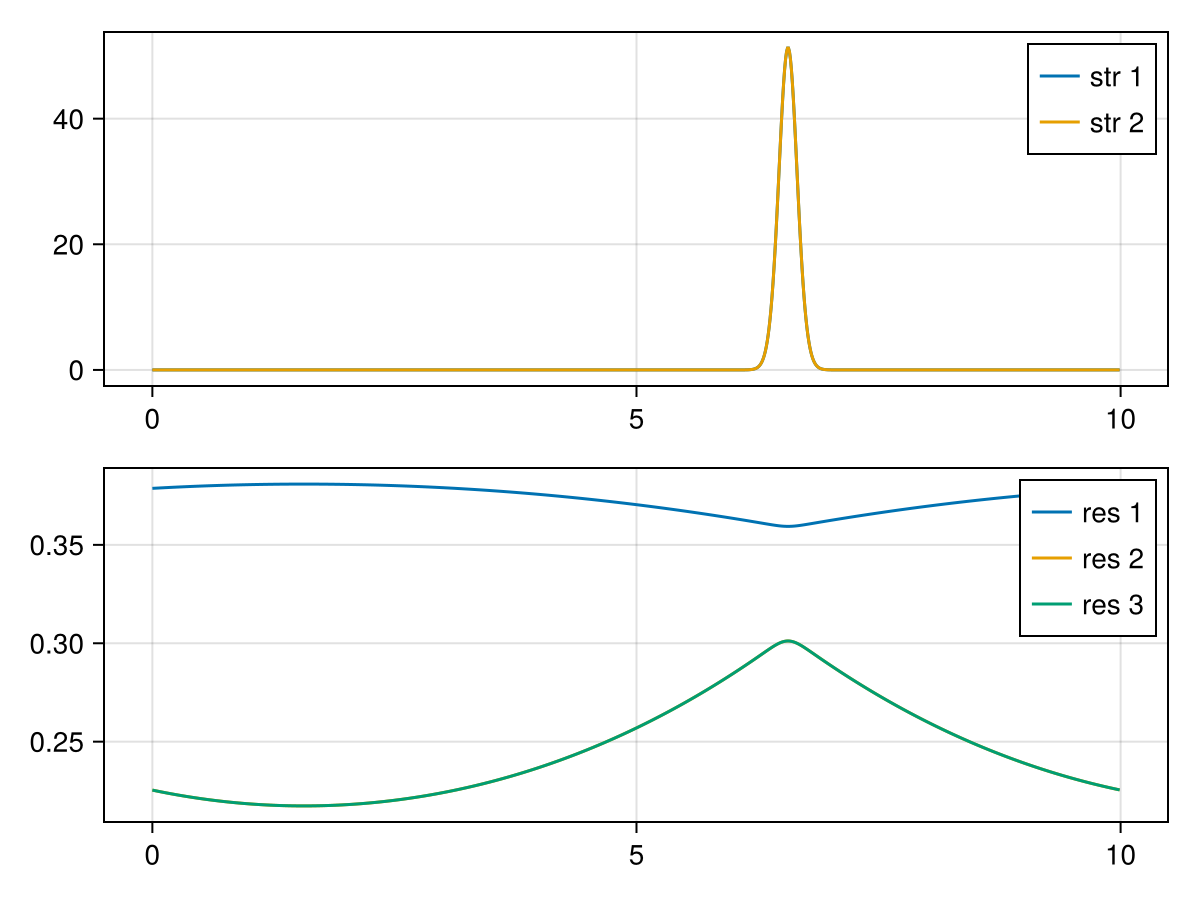

In [35]:
sssp = SteadyStateProblem(sp)
@time sssps = solve(sssp, DynamicSS(QNDF()); maxiters=1000)
display(sssps.retcode)
display(sssps.original.destats.nf)
plot_1dsmmicrm_sol_snap(sssps.prob.p, sssps.u)

## Spatial stuff - 2D!

In [92]:
ssize = (60,60)
su0 = expand_u0_to_size(ssize, usol)
psu0 = perturb_u0_uniform(get_Ns(p.p)..., su0, 0.1, 0.1)
space = make_cartesianspace_smart(length(ssize); dx=0.1, bcs=Periodic())
usenthreads = prod(ssize) >= 100 ? nthreads() : nothing
sp = make_smmicrm_problem_safe(
    psu0, 100000000, p.p, SA[Ds...], space, usenthreads;
)
size(sp.u0), sp.p.usenthreads, sp.p.space

((40, 60, 60), 1, CartesianSpace{2, Tuple{Periodic, Periodic}, Float64}([0.1, 0.1]))

#### Direct solver

In [ ]:
@time sps = solve(sp, QNDF(); maxiters=10000)
print_spatial_solution_stats(sps)

In [ ]:
sps.prob.p

In [ ]:
f = plot_2dsmmicrm_sol_snap_heatmap(sps, -1)

In [11]:
f = plot_smmicrm_sol_avgs(sps; plote=true)
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [12]:
f = plot_2dsmmicrm_sol_interactive_heatmap(sps)
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

## Saving/loading

In [61]:
save_object(datadir("minimalmodel", randname()*".jld2"), sps)

In [9]:
sps = load_object("../data/minimalmodel/fascinating_maybe_moving.jld2");
print_spatial_solution_stats(sps)

MaxIters
nf is 110126
solution has 8608 saved states
max resid is 0.00431203


# Extras

In [952]:
GC.gc()
empty!(Out)

Dict{Int64, Any}()